# Similar Recipes by Name

In [10]:
import pandas as pd

df = pd.read_csv('13k-recipes.csv')

# Combine relevant fields for embedding
df['text_for_embedding'] = (
    "Recipe: " + df['Title'] + ". " +  # Emphasize title
    "Ingredients: " + df['Cleaned_Ingredients'] + ". " +
    "Instructions: " + df['Instructions']
)


In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
batch_size = 512  # Adjust based on your RAM
embeddings = model.encode(
    df['text_for_embedding'].tolist(),
    batch_size=batch_size,
    show_progress_bar=True
)


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

In [11]:
import faiss
import numpy as np

embeddings = np.array(embeddings).astype('float32')
faiss.normalize_L2(embeddings)


In [12]:
index = faiss.IndexFlatIP(embeddings.shape[1])  # Inner product (cosine similarity)
index.add(embeddings)


In [14]:
query = "scrambled eggs"
query_vec = model.encode([query]).astype('float32')
faiss.normalize_L2(query_vec)

k = 5  # Number of similar recipes to retrieve
D, I = index.search(query_vec, k)

# Show the most similar recipes
for idx in I[0]:
    print(df.iloc[idx]['Title'])
    print(df.iloc[idx]['Ingredients'])
    print()


Scrambled Egg Pasta
['4 eggs', '1/2 cup grated Parmesan', '8 slices thick bacon, chopped', '1 onion, chopped', '4 cups al-dente cooked pasta', 'Salt and pepper to taste']

Saltie's Soft-Scrambled Eggs
['1 tsp unsalted butter', '2 eggs', 'Sea salt', 'Finely chopped herbs, for garnish']

Marblehead Soft Scrambled Egg, Corn, and Cheddar Cheese
['1 teaspoon clarified butter', 'regular butter, or ghee', '6 extra-large eggs', '1/3 cup feather-shredded cheddar cheese', '1/2 teaspoon heavy cream', 'A big handful of frozen corn kernels (about 1 cup)']

Moroccan-Style Potato and Egg Sandwiches
['4 large eggs', '1 tablespoon cumin seeds', '1/2 lb Italian frying peppers, cut into 2- by 1/4-inch strips', '1 large onion, halved lengthwise, then cut lengthwise into 1/4-inch-thick slices', '3/4 lb boiling potatoes, peeled and thinly sliced crosswise', '1/2 teaspoon salt', '1/4 teaspoon black pepper', '3 tablespoons extra-virgin olive oil', '4 Portuguese, challah, or kaiser rolls (about 4 inches in dia

# Recipes by Available Ingredients

In [15]:
# New code for ingredient-based index
df['ingredient_text'] = "Ingredients: " + df['Cleaned_Ingredients']
ingredient_embeddings = model.encode(df['ingredient_text'].tolist())
ingredient_embeddings = np.array(ingredient_embeddings).astype('float32')
faiss.normalize_L2(ingredient_embeddings)

# Build ingredient-focused index
ingredient_index = faiss.IndexFlatIP(ingredient_embeddings.shape[1])
ingredient_index.add(ingredient_embeddings)


In [17]:
user_ingredients = ["eggs", "milk", "cheese"]
query = "Ingredients: " + ", ".join(user_ingredients)
query_vec = model.encode([query]).astype('float32')
faiss.normalize_L2(query_vec)

D, I = ingredient_index.search(query_vec, k=5)

# Show the most similar recipes
for idx in I[0]:
    print(df.iloc[idx]['Title'])
    print(df.iloc[idx]['Ingredients'])
    print()



Slow-Cooker Macaroni and Cheese
['1 1/2 cups skim or low-fat milk', '1 (15-ounce) can evaporated skim milk', '1 large egg, beaten', '1/4 teaspoon salt', 'Large pinch of freshly ground black pepper', '1 1/2 cups shredded medium or sharp cheddar cheese, such as Oregon Tillamook, Vermont Colby, or Wisconsin longhorn', '8 ounces elbow macaroni (about 2 cups)', '2 tablespoons freshly grated or shredded Parmesan cheese']

Mahón Cheese Ice Cream
['3 cups whole milk', '3 large eggs', '1/2 cup sugar', '4 ounces cream cheese, softened', '4 ounces Spanish Mahón or Danish Fontina cheese, rind discarded and cheese coarsely grated (1 cup)', '1/2 teaspoon vanilla', 'an instant-read thermometer; an ice cream maker']

Hard-Boiled Eggs
['4–8 large eggs']

Jammy Soft-Boiled Eggs
['4–8 large eggs']

Fearless Sous Vide Poached Eggs
['6 large eggs']



# Ingredient Substitutions

In [26]:
import re

def normalize_ingredient(ingredient):
    ingredient = ingredient.lower().strip()
    # Remove common descriptors and usage notes
    ingredient = re.sub(r'\b(sweet|unsalted|salted|fresh|dried|ground|chopped|sliced|melted|softened|spiced|buttered)\b', '', ingredient)
    ingredient = re.sub(r',.*', '', ingredient)  # Remove anything after a comma
    ingredient = re.sub(r'\(.*?\)', '', ingredient)  # Remove anything in parentheses
    ingredient = re.sub(r'\bor\b.*', '', ingredient)  # Remove "or ..." alternatives
    ingredient = re.sub(r'for .*', '', ingredient)  # Remove "for frying", etc.
    ingredient = re.sub(r'\s+', ' ', ingredient)  # Remove extra spaces
    return ingredient.strip()


all_ingredients = set()
for ingredients in df['Cleaned_Ingredients']:
    for ing in eval(ingredients):
        norm = normalize_ingredient(ing)
        if norm:  # Ignore empty strings
            all_ingredients.add(norm)
ingredient_list = sorted(all_ingredients)


ingredient_embeddings = model.encode(ingredient_list).astype('float32')
faiss.normalize_L2(ingredient_embeddings)

# Build substitution index
substitution_index = faiss.IndexFlatIP(ingredient_embeddings.shape[1])
substitution_index.add(ingredient_embeddings)

In [28]:
def get_substitutes(target_ingredient: str, k=10):
    query_vec = model.encode([target_ingredient]).astype('float32')
    faiss.normalize_L2(query_vec)
    D, I = substitution_index.search(query_vec, k)
    return [ingredient_list[i] for i in I[0]]

print(get_substitutes("butter"))  # Output: ["margarine", "coconut oil", "olive oil"]


['butter', 'cup butter', 'regular butter', 'extra butter', '1 butter', 'a dab of butter', 'additional butter', 'peanut butter', 'pat of butter', 'dots of butter']


In [29]:
dairy_items = ["butter", "milk", "cream", "cheese", "yogurt"]

for item in dairy_items:
    print(f"Nearest neighbors for: {item}")
    print(get_substitutes(item, k=5))
    print()


Nearest neighbors for: butter
['butter', 'cup butter', 'regular butter', 'extra butter', '1 butter']

Nearest neighbors for: milk
['milk', 'whole milk', 'dry milk', 'a little milk', 'coconut milk']

Nearest neighbors for: cream
['cream', 'heavy cream', 'whipping cream', 'lemon cream', 'cream cheese']

Nearest neighbors for: cheese
['cheese', 'cheeses', 'cream cheese', 'goat cheese', 'shredded cheese']

Nearest neighbors for: yogurt
['yogurt', 'plain yogurt', 'honey yogurt', 'greek yogurt', '1 cup yogurt']



In [30]:
from sklearn.metrics.pairwise import cosine_similarity

# Get indices of ingredients
butter_idx = ingredient_list.index("butter")
milk_idx = ingredient_list.index("milk")

# Compute cosine similarity
similarity = cosine_similarity(
    [ingredient_embeddings[butter_idx]],
    [ingredient_embeddings[milk_idx]]
)[0][0]

print(f"Cosine similarity between 'butter' and 'milk': {similarity:.3f}")


Cosine similarity between 'butter' and 'milk': 0.568


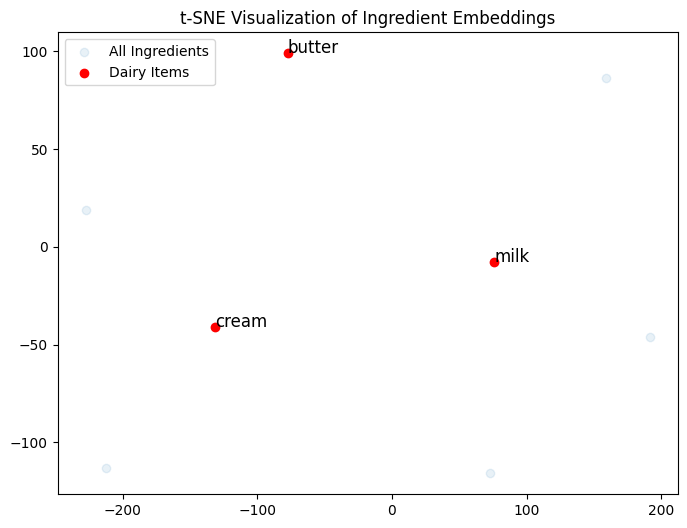

In [1]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # MUST BE FIRST LINE

import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer

# --- Normalization function (unchanged) ---
def normalize_ingredient(ingredient):
    ingredient = ingredient.lower().strip()
    ingredient = re.sub(r'\b(sweet|unsalted|salted|fresh|dried|ground|chopped|sliced|melted|softened|spiced|buttered)\b', '', ingredient)
    ingredient = re.sub(r',.*', '', ingredient)
    ingredient = re.sub(r'\(.*?\)', '', ingredient)
    ingredient = re.sub(r'\bor\b.*', '', ingredient)
    ingredient = re.sub(r'for .*', '', ingredient)
    ingredient = re.sub(r'\s+', ' ', ingredient)
    return ingredient.strip()

# --- Load your data (replace with actual CSV loading) ---
# df = pd.read_csv('13k-recipes.csv')
# For demonstration, use your example data:
example_ingredients = [
    "['butter', 'melted butter', 'butter (if needed)', 'butter, for frying']",
    "['milk', 'whole milk', 'skim milk', 'milk powder']",
    "['cream', 'heavy cream', 'whipping cream']"
]

all_ingredients = set()
for ingredients in example_ingredients:
    for ing in eval(ingredients):
        norm = normalize_ingredient(ing)
        if norm:
            all_ingredients.add(norm)
ingredient_list = sorted(all_ingredients)

# --- Generate embeddings ---
model = SentenceTransformer('all-MiniLM-L6-v2')
ingredient_embeddings = model.encode(ingredient_list).astype('float32')

# --- t-SNE Visualization ---
tsne = TSNE(n_components=2, random_state=42, perplexity=5)  # Reduced perplexity for small data
embeddings_2d = tsne.fit_transform(ingredient_embeddings)

# --- Plot ---
dairy_items = ["butter", "milk", "cream"]
dairy_indices = [ingredient_list.index(item) for item in dairy_items if item in ingredient_list]

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.1, label="All Ingredients")
plt.scatter(embeddings_2d[dairy_indices, 0], embeddings_2d[dairy_indices, 1], color='red', label="Dairy Items")
for idx in dairy_indices:
    plt.text(embeddings_2d[idx, 0], embeddings_2d[idx, 1], ingredient_list[idx], fontsize=12)
plt.legend()
plt.title("t-SNE Visualization of Ingredient Embeddings")
plt.show()


In [2]:
from sklearn.metrics.pairwise import cosine_similarity

butter_idx = ingredient_list.index("butter")
milk_idx = ingredient_list.index("milk")
cream_idx = ingredient_list.index("cream")

print("butter/milk similarity:", cosine_similarity([ingredient_embeddings[butter_idx]], [ingredient_embeddings[milk_idx]])[0][0])
print("butter/cream similarity:", cosine_similarity([ingredient_embeddings[butter_idx]], [ingredient_embeddings[cream_idx]])[0][0])
print("milk/cream similarity:", cosine_similarity([ingredient_embeddings[milk_idx]], [ingredient_embeddings[cream_idx]])[0][0])


butter/milk similarity: 0.5680218
butter/cream similarity: 0.5759177
milk/cream similarity: 0.56005424


In [20]:
original_ingredient = "butter"
substitutes = get_substitutes(original_ingredient)

# Find recipes using substitutes
query = "Ingredients: " + ", ".join(substitutes)
query_vec = model.encode([query]).astype('float32')
faiss.normalize_L2(query_vec)
D, I = ingredient_index.search(query_vec, k=5)


In [3]:
from rdflib import Graph, Namespace, URIRef
from rdflib.namespace import RDFS

# Load FoodOn ontology
g = Graph()
g.parse("foodon-base.owl", format="xml")  # Path to your FoodOn OWL file

# Define the FoodOn namespace
FOODON = Namespace("http://purl.obolibrary.org/obo/")

def get_sibling_classes(label):
    # Find the URI for the ingredient
    query_uri = None
    for s, p, o in g.triples((None, RDFS.label, None)):
        if o.lower() == label.lower():
            query_uri = s
            break
    if not query_uri:
        print(f"No class found for label: {label}")
        return []

    # Find the parent class
    parent = None
    for s, p, o in g.triples((query_uri, RDFS.subClassOf, None)):
        parent = o
        break
    if not parent:
        print(f"No parent class found for {label}")
        return []

    # Find all subclasses (siblings) of the parent
    siblings = []
    for s, p, o in g.triples((None, RDFS.subClassOf, parent)):
        if s != query_uri:
            sib_label = g.value(s, RDFS.label)
            if sib_label:
                siblings.append(str(sib_label))
    return siblings

# Example usage:
print(get_sibling_classes("chicken"))  # Might return ["turkey", "duck", ...]


['broiler chicken meat food product', 'rock cornish fowl meat food product', 'chicken nugget', 'chicken (whole or pieces)', 'piece of chicken meat', 'chicken crackling', 'chicken (canned)', 'chicken stick', 'chicken spread', 'chicken loaf lunch meat', 'chicken (frozen)', 'chicken croquette', 'chicken (artificially colored)', 'ova (hen)', 'chicken (fried)', 'chicken frankfurter', 'chicken roll', 'chicken (strained)', 'chicken (battered, deep-fried)', 'chicken (breaded)', 'chicken (baked)', 'chicken (freeze-dried)', 'chicken kiev']
